# Telescope Signal Classification — Review 1 (Part A)

The goal is to distinguish gamma-ray signals (`g`) from hadron background (`h`) using ten telescope measurements. The five Part A classifiers are trained on one stratified split so their test scores are directly comparable.

**Review 1 flow:** data audit → EDA → cleaning and feature engineering → preprocessing → five classifiers → comparison.

## 1. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree

sns.set_theme(style="whitegrid", palette="colorblind")
RANDOM_STATE = 42
CLASS_ORDER = ["g", "h"]

## 2. Load and audit the data

The CSV contains an exported row-number column, which is not a telescope measurement and is removed. The audit checks shape, data types, missing values, duplicates, and class balance before any modelling decisions are made.

In [2]:
def find_data_file(filename):
    candidates = [
        Path.cwd() / "data" / filename,
        Path.cwd().parent / "data" / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find {filename} from {Path.cwd()}")


data_path = find_data_file("telescope_data.csv")
telescope_raw = pd.read_csv(data_path)
telescope = telescope_raw.drop(columns=["Unnamed: 0"], errors="ignore")

print(f"Raw shape: {telescope_raw.shape}")
print(f"Shape after removing the row-number column: {telescope.shape}")
display(telescope.head())

Raw shape: (19020, 12)
Shape after removing the row-number column: (19020, 11)


    fLength    fWidth   fSize   fConc  ...  fM3Trans   fAlpha     fDist  class
0   28.7967   16.0021  2.6449  0.3918  ...   -8.2027  40.0920   81.8828      g
1   31.6036   11.7235  2.5185  0.5303  ...   -9.9574   6.3609  205.2610      g
2  162.0520  136.0310  4.0612  0.0374  ...  -45.2160  76.9600  256.7880      g
3   23.8172    9.5728  2.3385  0.6147  ...   -7.1513  10.4490  116.7370      g
4   75.1362   30.9205  3.1611  0.3168  ...   21.8393   4.6480  356.4620      g

[5 rows x 11 columns]

In [3]:
audit = pd.DataFrame(
    {
        "data_type": telescope.dtypes.astype(str),
        "missing_values": telescope.isna().sum(),
        "unique_values": telescope.nunique(),
    }
)

print(f"Duplicate rows: {telescope.duplicated().sum():,}")
display(audit)
display(telescope.describe().T)
display(telescope["class"].value_counts().rename_axis("class").to_frame("count"))

Duplicate rows: 115


         data_type  missing_values  unique_values
fLength    float64               0          18643
fWidth     float64               0          18200
fSize      float64               0           7228
fConc      float64               0           6410
fConc1     float64               0           4421
fAsym      float64               0          18704
fM3Long    float64               0          18693
fM3Trans   float64               0          18390
fAlpha     float64               0          17981
fDist      float64               0          18437
class          str               0              2

            count        mean        std  ...        50%         75%       max
fLength   19020.0   53.250154  42.364855  ...   37.14770   70.122175  334.1770
fWidth    19020.0   22.180966  18.346056  ...   17.13990   24.739475  256.3820
fSize     19020.0    2.825017   0.472599  ...    2.73960    3.101600    5.3233
fConc     19020.0    0.380327   0.182813  ...    0.35415    0.503700    0.8930
fConc1    19020.0    0.214657   0.110511  ...    0.19650    0.285225    0.6752
fAsym     19020.0   -4.331745  59.206062  ...    4.01305   24.063700  575.2407
fM3Long   19020.0   10.545545  51.000118  ...   15.31410   35.837800  238.3210
fM3Trans  19020.0    0.249726  20.827439  ...    0.66620   10.946425  179.8510
fAlpha    19020.0   27.645707  26.103621  ...   17.67950   45.883550   90.0000
fDist     19020.0  193.818026  74.731787  ...  191.85145  240.563825  495.5610

[10 rows x 8 columns]

       count
class       
g      12332
h       6688

## 3. Exploratory data analysis

The target count plot checks imbalance. The feature histograms compare each class, the heatmap checks correlation, and the scatter plots show whether two features alone can separate the classes.

<ipython-input-1-e4ee42fb6473>:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


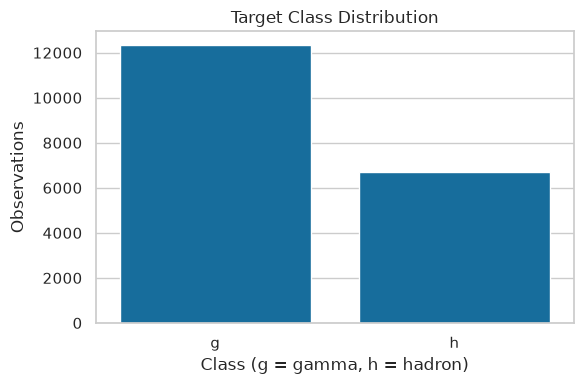

In [4]:
feature_columns = telescope.drop(columns="class").columns.tolist()

plt.figure(figsize=(6, 4))
sns.countplot(data=telescope, x="class", order=CLASS_ORDER)
plt.title("Target Class Distribution")
plt.xlabel("Class (g = gamma, h = hadron)")
plt.ylabel("Observations")
plt.tight_layout()
plt.show()

**Observation.** Gamma observations are more common than hadron observations. A stratified split is therefore used later so both sets keep the original class proportions. Weighted metrics are reported so performance reflects both classes.

<ipython-input-1-30ddd35685d6>:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


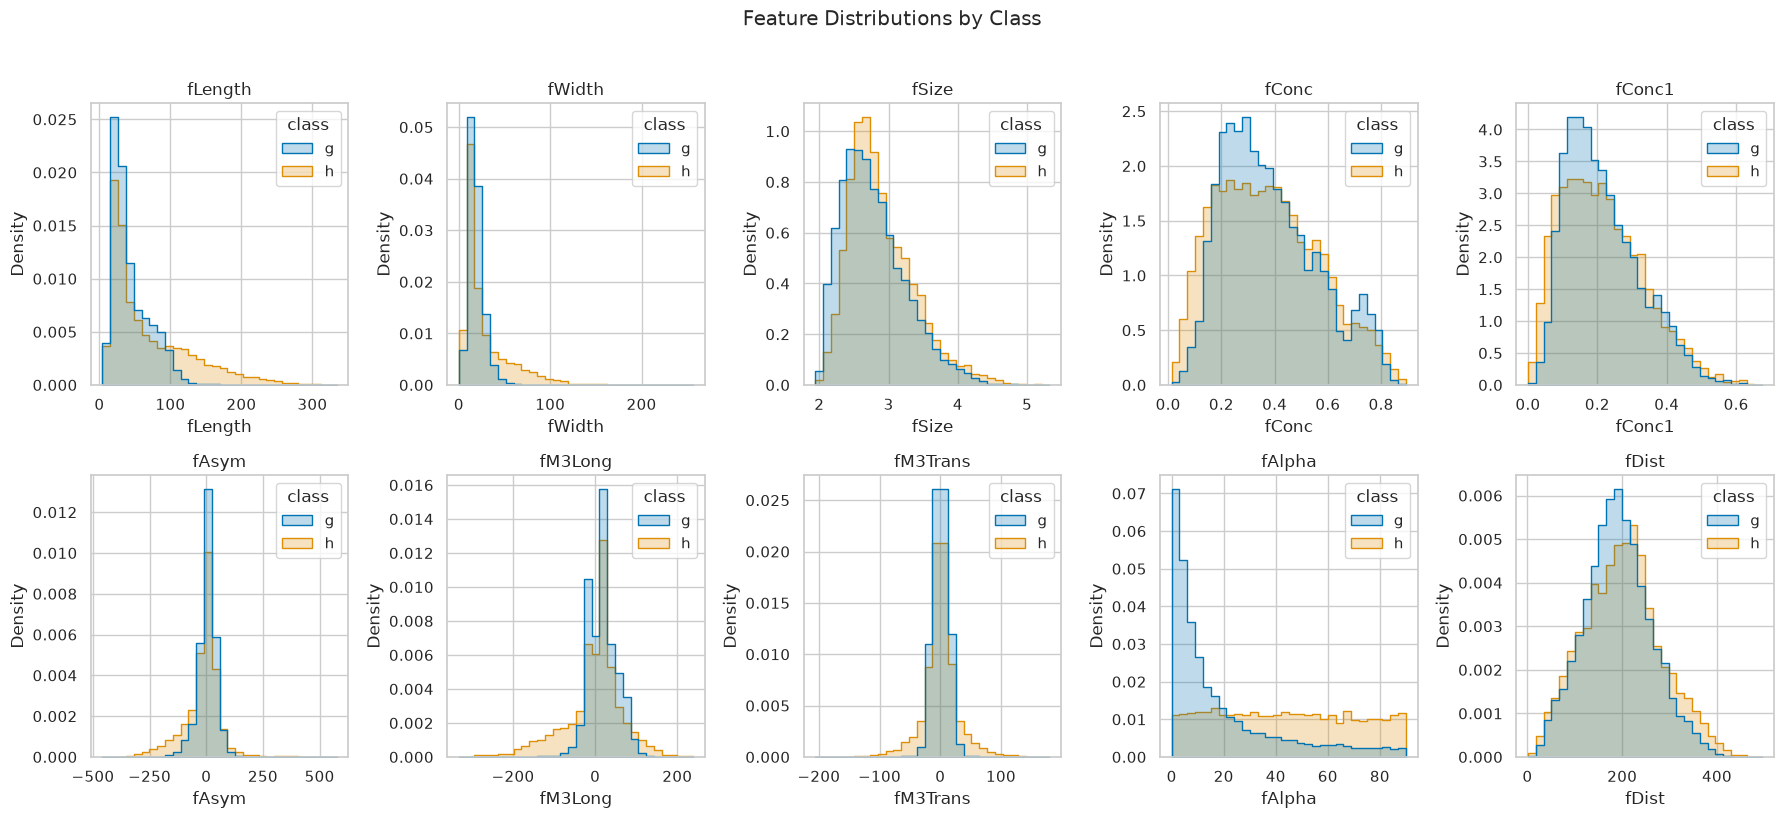

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for axis, feature in zip(axes.ravel(), feature_columns):
    sns.histplot(
        data=telescope,
        x=feature,
        hue="class",
        hue_order=CLASS_ORDER,
        bins=30,
        stat="density",
        common_norm=False,
        element="step",
        ax=axis,
    )
    axis.set_title(feature)
    axis.set_ylabel("Density")
plt.suptitle("Feature Distributions by Class", y=1.02)
plt.tight_layout()
plt.show()

**Observation.** Most measurements overlap across the two classes, but their centres and spreads are not identical. No single feature cleanly separates gamma from hadron observations, so the models use the full feature set.

<ipython-input-1-17934974da2c>:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


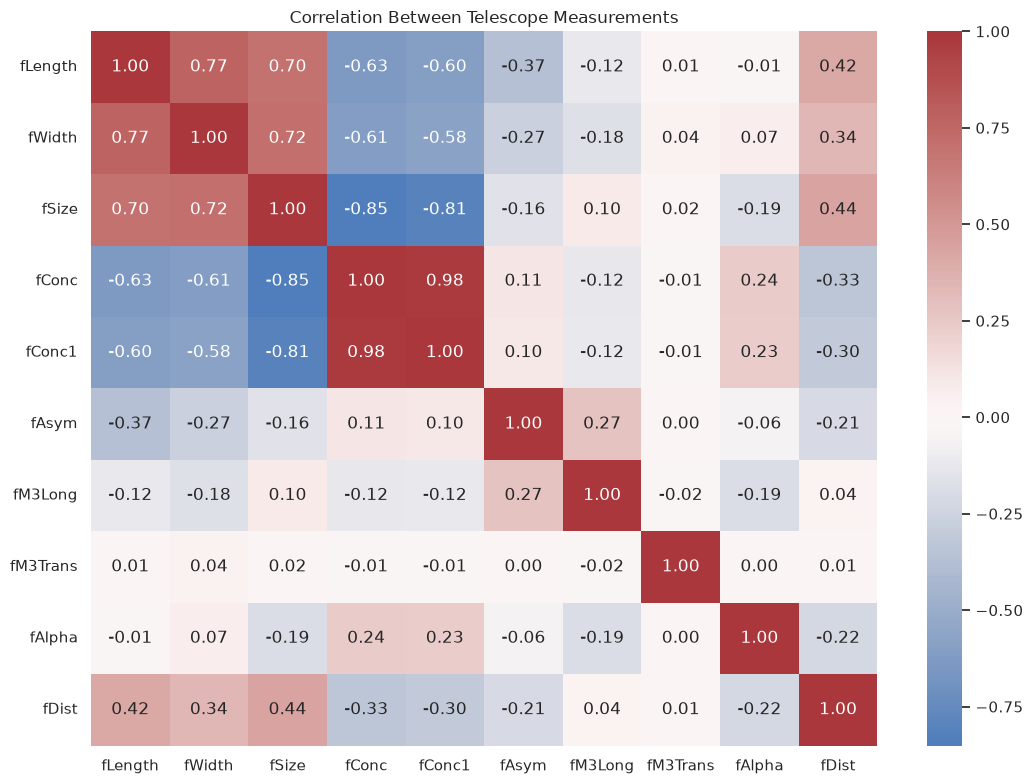

In [6]:
plt.figure(figsize=(11, 8))
sns.heatmap(
    telescope[feature_columns].corr(),
    cmap="vlag",
    center=0,
    annot=True,
    fmt=".2f",
)
plt.title("Correlation Between Telescope Measurements")
plt.tight_layout()
plt.show()

**Observation.** Several shape and concentration measurements are correlated. This can make a linear model's individual coefficients less stable, while tree-based models can choose useful thresholds without requiring independent inputs.

<ipython-input-1-aeffdc1715d5>:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


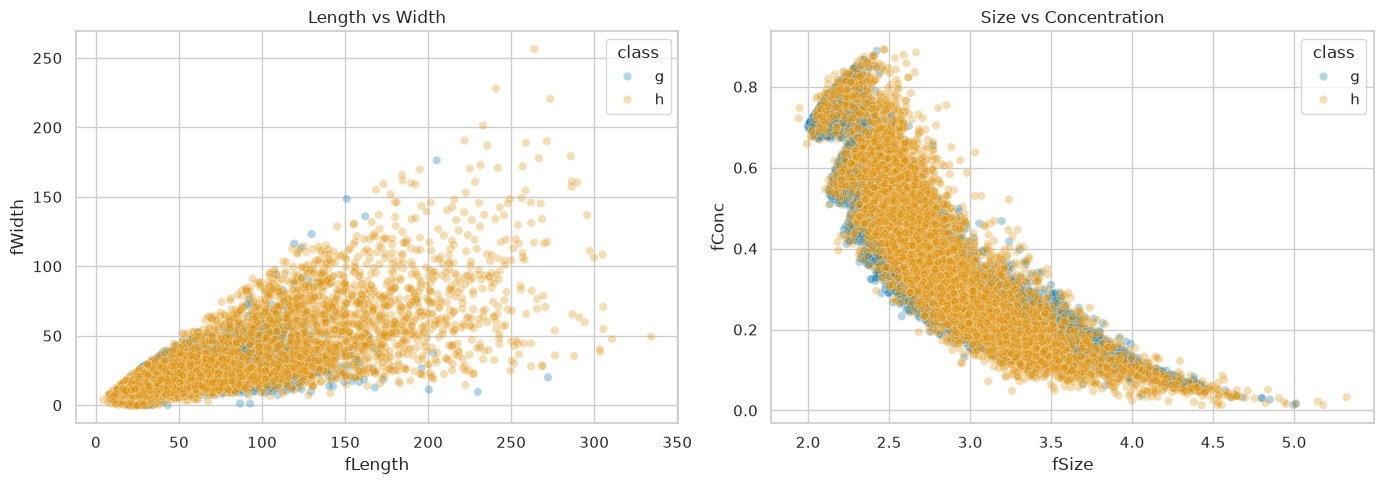

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(
    data=telescope,
    x="fLength",
    y="fWidth",
    hue="class",
    hue_order=CLASS_ORDER,
    alpha=0.30,
    ax=axes[0],
)
axes[0].set_title("Length vs Width")

sns.scatterplot(
    data=telescope,
    x="fSize",
    y="fConc",
    hue="class",
    hue_order=CLASS_ORDER,
    alpha=0.30,
    ax=axes[1],
)
axes[1].set_title("Size vs Concentration")
plt.tight_layout()
plt.show()

**Observation.** Both scatter plots contain substantial class overlap. This suggests that a straight decision boundary may be too simple and gives a reason to compare Logistic Regression with nonlinear KNN, Decision Tree, and RBF-SVC models.

<ipython-input-1-481313674deb>:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


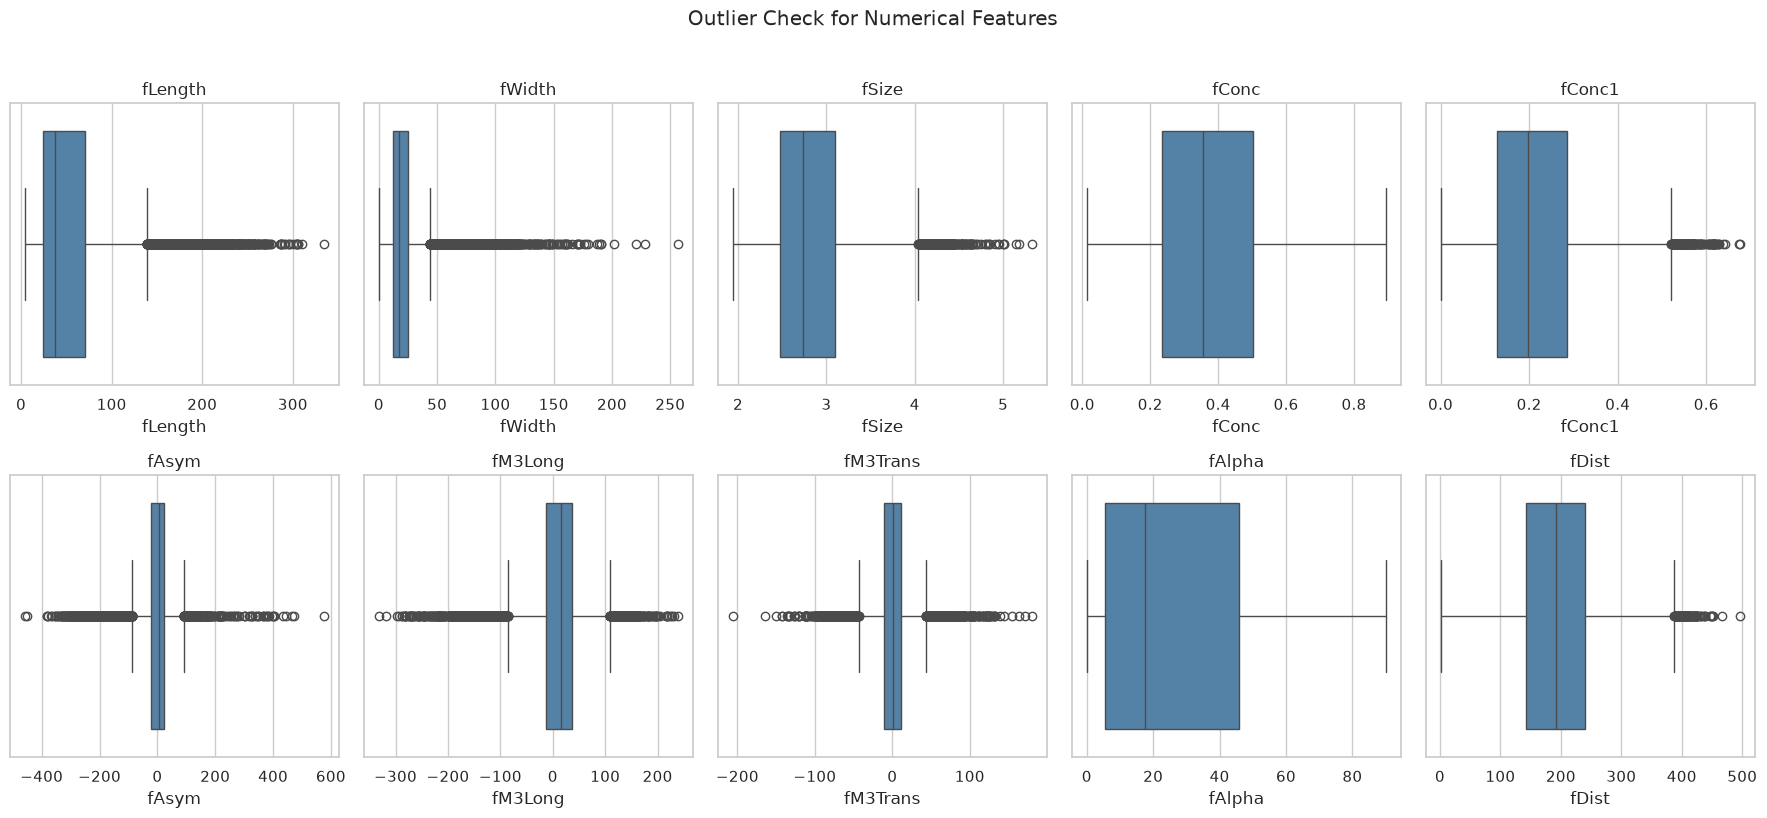

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for axis, feature in zip(axes.ravel(), feature_columns):
    sns.boxplot(data=telescope, x=feature, ax=axis, color="steelblue")
    axis.set_title(feature)
plt.suptitle("Outlier Check for Numerical Features", y=1.02)
plt.tight_layout()
plt.show()

**Outlier decision.** The box plots contain long tails, but these measurements represent real shower events rather than impossible values. They are retained; removing them could discard the unusual observations that the classifier needs to recognise. Standardisation limits scale differences for distance- and margin-based models.

## 4. Clean and engineer features

Exact duplicate observations are removed before splitting so the same measurement cannot appear in both training and test data. `length_width_ratio` captures shower elongation in one value and is a reasonable class-discrimination feature. Any division issue is left as missing and handled inside the training pipeline.

In [9]:
model_data = telescope.drop_duplicates().reset_index(drop=True).copy()
model_data["length_width_ratio"] = (
    model_data["fLength"] / model_data["fWidth"].replace(0, np.nan)
)
model_data["length_width_ratio"] = model_data[
    "length_width_ratio"
].replace([np.inf, -np.inf], np.nan)

print(f"Removed duplicate rows: {len(telescope) - len(model_data):,}")
print(f"Rows available for modelling: {len(model_data):,}")
model_data[["fLength", "fWidth", "length_width_ratio"]].head()

Removed duplicate rows: 115
Rows available for modelling: 18,905
Out[0]: 
    fLength    fWidth  length_width_ratio
0   28.7967   16.0021            1.799558
1   31.6036   11.7235            2.695748
2  162.0520  136.0310            1.191287
3   23.8172    9.5728            2.488008
4   75.1362   30.9205            2.429980


## 5. Split and preprocess

The split is performed once and reused by every classifier. Median imputation and standardisation are fitted only on training folds through a pipeline, which prevents information from the test set leaking into preprocessing.

In [10]:
X = model_data.drop(columns="class")
y = model_data["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

scaled_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
unscaled_preprocessor = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median"))]
)

split_summary = pd.DataFrame(
    {
        "rows": [len(X_train), len(X_test)],
        "gamma_share": [
            y_train.eq("g").mean(),
            y_test.eq("g").mean(),
        ],
    },
    index=["Training set", "Test set"],
)
split_summary

Out[0]: 
               rows  gamma_share
Training set  15124     0.652341
Test set       3781     0.652208


## 6. Shared evaluation functions

Accuracy gives the overall hit rate. Weighted precision, recall, and F1 account for class support, while ROC-AUC measures ranking quality across thresholds. Every model also gets a confusion matrix using the same class order.

In [11]:
results = []
fitted_models = {}
test_predictions = {}


def positive_class_scores(model, features, positive_label="g"):
    classes = list(model.classes_)
    if hasattr(model, "predict_proba"):
        return model.predict_proba(features)[:, classes.index(positive_label)]

    scores = model.decision_function(features)
    return scores if classes[1] == positive_label else -scores


def evaluate_classifier(name, estimator):
    model = clone(estimator)
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    scores = positive_class_scores(model, X_test)

    row = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision (weighted)": precision_score(
            y_test, predictions, average="weighted", zero_division=0
        ),
        "Recall (weighted)": recall_score(
            y_test, predictions, average="weighted", zero_division=0
        ),
        "F1 (weighted)": f1_score(
            y_test, predictions, average="weighted", zero_division=0
        ),
        "ROC-AUC": roc_auc_score(y_test.eq("g"), scores),
    }
    results.append(row)
    fitted_models[name] = model
    test_predictions[name] = predictions

    display(pd.DataFrame([row]).set_index("Model").round(4))

    matrix = confusion_matrix(y_test, predictions, labels=CLASS_ORDER)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=CLASS_ORDER,
        yticklabels=CLASS_ORDER,
    )
    plt.title(f"{name} — Confusion Matrix")
    plt.xlabel("Predicted class")
    plt.ylabel("Actual class")
    plt.tight_layout()
    plt.show()
    return model


def comparison_table():
    return (
        pd.DataFrame(results)
        .sort_values("F1 (weighted)", ascending=False)
        .reset_index(drop=True)
    )

## Model 1: Logistic Regression

Logistic Regression is the linear baseline. Standardised coefficients make the direction and relative strength of each feature easier to compare.

### Step 1 — Train and evaluate the baseline

<ipython-input-1-03e14cd67bbe>:56: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


                     Accuracy  Precision (weighted)  ...  F1 (weighted)  ROC-AUC
Model                                                ...                        
Logistic Regression    0.7932                0.7904  ...          0.785   0.8392

[1 rows x 5 columns]

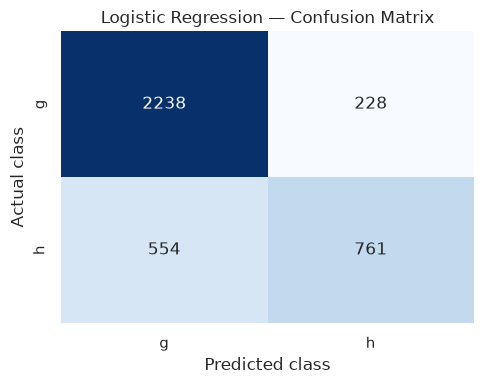

In [12]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(scaled_preprocessor)),
        (
            "classifier",
            LogisticRegression(max_iter=2_000, random_state=RANDOM_STATE),
        ),
    ]
)

logistic_model = evaluate_classifier(
    "Logistic Regression", logistic_pipeline
)

### Step 2 — Interpret coefficients

In [13]:
logistic_classifier = logistic_model.named_steps["classifier"]
logistic_coefficients = pd.DataFrame(
    {
        "Feature": X.columns,
        "Coefficient": logistic_classifier.coef_[0],
    }
)
logistic_coefficients["Odds ratio"] = np.exp(
    logistic_coefficients["Coefficient"]
)
logistic_coefficients["Absolute coefficient"] = logistic_coefficients[
    "Coefficient"
].abs()

logistic_coefficients.sort_values(
    "Absolute coefficient", ascending=False
).head(10)

Out[0]: 
               Feature  Coefficient  Odds ratio  Absolute coefficient
0              fLength     1.193792    3.299569              1.193792
8               fAlpha     1.173747    3.234089              1.173747
10  length_width_ratio    -1.088775    0.336629              1.088775
4               fConc1     0.579956    1.785960              0.579956
6              fM3Long    -0.341287    0.710855              0.341287
2                fSize     0.317133    1.373185              0.317133
1               fWidth     0.148891    1.160546              0.148891
9                fDist     0.052001    1.053377              0.052001
3                fConc     0.031308    1.031804              0.031308
7             fM3Trans    -0.014753    0.985356              0.014753


### Model 1 takeaway

This is the reference model for Part A. A positive coefficient increases the model's log-odds for class `h`, while a negative coefficient shifts the prediction toward `g`. The confusion matrix shows where a linear boundary is insufficient.

## Model 2: K-Nearest Neighbours

KNN predicts from nearby training observations. Scaling is essential because its distances should not be dominated by whichever measurement has the largest numeric range.

### Step 1 — Tune the number of neighbours

In [14]:
knn_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(scaled_preprocessor)),
        ("classifier", KNeighborsClassifier()),
    ]
)
knn_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid={
        "classifier__n_neighbors": [3, 5, 7, 9, 11, 15],
        "classifier__weights": ["uniform", "distance"],
    },
    scoring="f1_weighted",
    cv=3,
    n_jobs=-1,
)
knn_search.fit(X_train, y_train)

print("Best KNN parameters:", knn_search.best_params_)
print(f"Best CV weighted F1: {knn_search.best_score_:.4f}")

Best KNN parameters: {'classifier__n_neighbors': 9, 'classifier__weights': 'distance'}
Best CV weighted F1: 0.8296


### Step 2 — Evaluate the selected KNN model

<ipython-input-1-03e14cd67bbe>:56: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


                      Accuracy  Precision (weighted)  ...  F1 (weighted)  ROC-AUC
Model                                                 ...                        
K-Nearest Neighbours    0.8434                0.8495  ...         0.8357   0.8952

[1 rows x 5 columns]

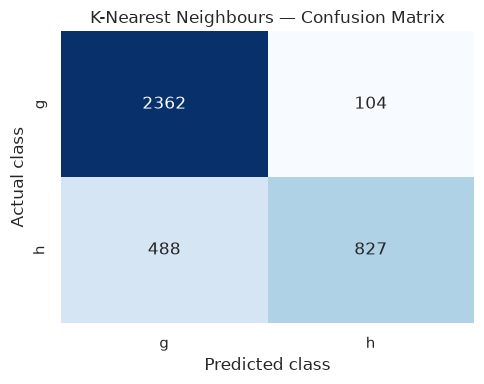

In [15]:
knn_model = evaluate_classifier(
    "K-Nearest Neighbours", knn_search.best_estimator_
)

### Model 2 takeaway

The selected neighbour count balances noisy local decisions against excessive smoothing. Compare its F1 and confusion matrix with Logistic Regression to see whether local class structure improves the result.

## Model 3: Gaussian Naive Bayes

Gaussian Naive Bayes is a fast probabilistic baseline. It treats features as conditionally independent within each class—an intentionally strong assumption given the correlations seen in the heatmap.

### Step 1 — Train and evaluate Gaussian Naive Bayes

<ipython-input-1-03e14cd67bbe>:56: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


                      Accuracy  Precision (weighted)  ...  F1 (weighted)  ROC-AUC
Model                                                 ...                        
Gaussian Naive Bayes    0.6683                0.7178  ...         0.6762   0.7534

[1 rows x 5 columns]

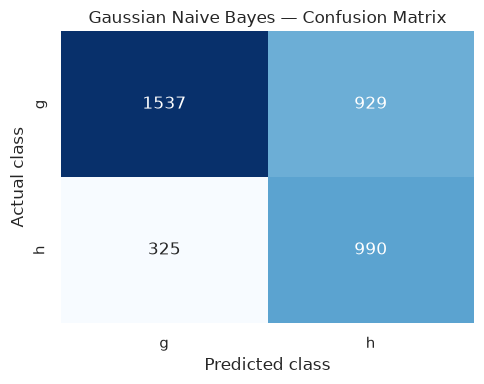

In [16]:
naive_bayes_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(scaled_preprocessor)),
        ("classifier", GaussianNB()),
    ]
)
naive_bayes_model = evaluate_classifier(
    "Gaussian Naive Bayes", naive_bayes_pipeline
)

### Model 3 takeaway

Naive Bayes is useful as a simple benchmark. A gap behind the other models would be consistent with its independence and Gaussian-shape assumptions being too restrictive for these correlated measurements.

## Model 4: Decision Tree Classifier

A Decision Tree learns readable threshold rules and can model nonlinear interactions. Depth and leaf size are tuned to control overfitting; scaling is unnecessary for threshold splits.

### Step 1 — Tune tree complexity

In [17]:
tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(unscaled_preprocessor)),
        (
            "classifier",
            DecisionTreeClassifier(
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
tree_search = GridSearchCV(
    estimator=tree_pipeline,
    param_grid={
        "classifier__max_depth": [4, 6, 8, 10, None],
        "classifier__min_samples_leaf": [1, 5, 10],
    },
    scoring="f1_weighted",
    cv=3,
    n_jobs=-1,
)
tree_search.fit(X_train, y_train)

print("Best Decision Tree parameters:", tree_search.best_params_)
print(f"Best CV weighted F1: {tree_search.best_score_:.4f}")

Best Decision Tree parameters: {'classifier__max_depth': 8, 'classifier__min_samples_leaf': 10}
Best CV weighted F1: 0.8340


### Step 2 — Evaluate and visualise the selected tree

<ipython-input-1-03e14cd67bbe>:56: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
<ipython-input-1-05c1f09e0ad1>:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


                          Accuracy  ...  ROC-AUC
Model                               ...         
Decision Tree Classifier    0.8474  ...   0.8895

[1 rows x 5 columns]

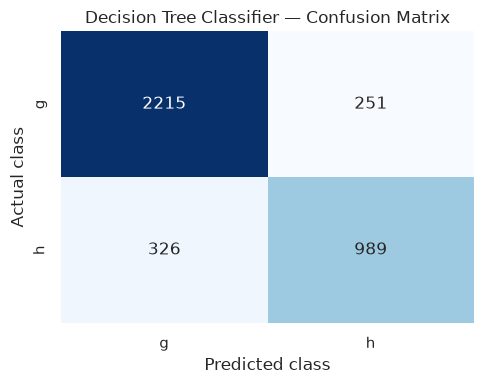

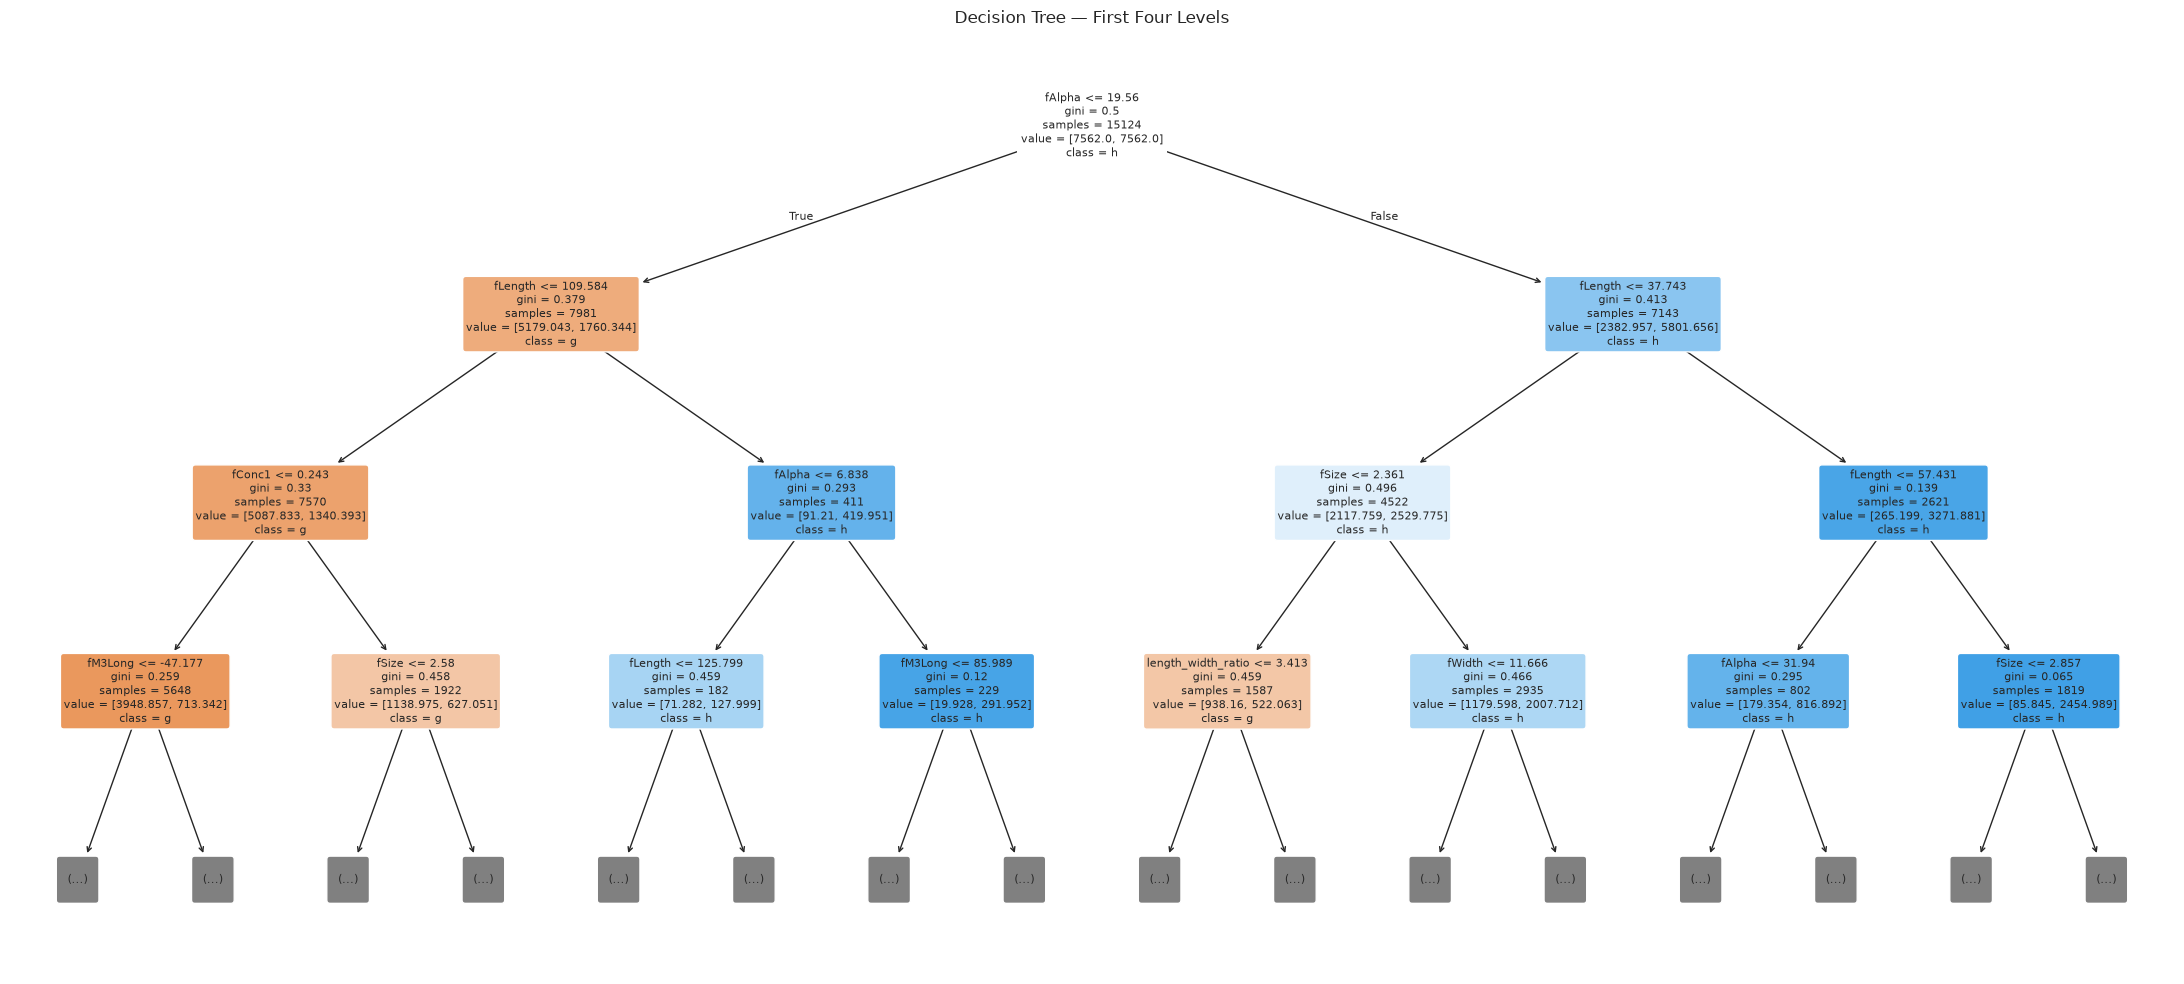

In [18]:
tree_model = evaluate_classifier(
    "Decision Tree Classifier", tree_search.best_estimator_
)
tree_classifier = tree_model.named_steps["classifier"]

plt.figure(figsize=(22, 10))
plot_tree(
    tree_classifier,
    feature_names=X.columns,
    class_names=CLASS_ORDER,
    max_depth=3,
    filled=True,
    rounded=True,
    fontsize=8,
)
plt.title("Decision Tree — First Four Levels")
plt.tight_layout()
plt.show()

<ipython-input-1-7127cff320d4>:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


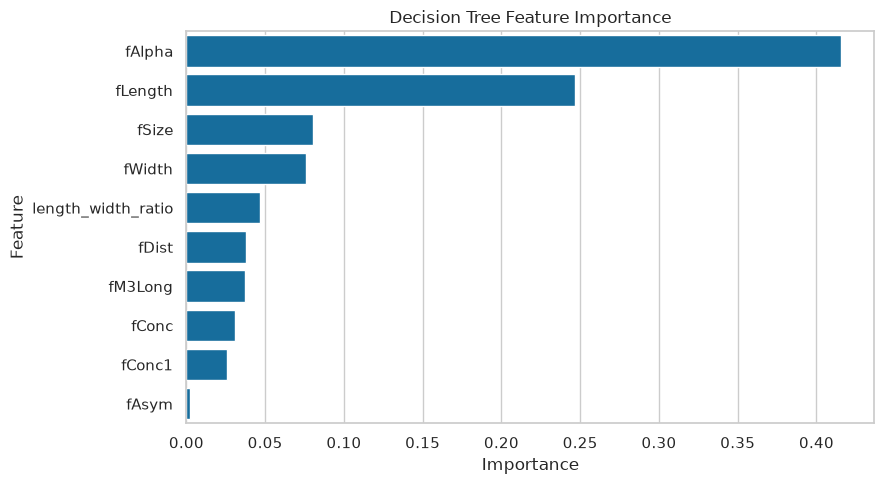

In [19]:
tree_importance = (
    pd.Series(tree_classifier.feature_importances_, index=X.columns)
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(9, 5))
sns.barplot(x=tree_importance.values, y=tree_importance.index)
plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Model 4 takeaway

The tree exposes the first decision rules and the measurements used most often. Its training controls and balanced class weights aim to improve hadron detection without allowing an unrestricted tree to memorise the training data.

## Model 5: Support Vector Machine (SVC)

SVC maximises the margin between classes. The linear kernel tests a straight boundary, while the RBF kernel can bend around overlapping regions. Both `C` and the kernel are selected using training data only.

### Step 1 — Tune `C` and the kernel

In [20]:
svc_tuning_size = min(8_000, len(X_train))
svc_tuning_rows = X_train.sample(
    n=svc_tuning_size, random_state=RANDOM_STATE
).index

svc_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(scaled_preprocessor)),
        ("classifier", SVC()),
    ]
)
svc_search = GridSearchCV(
    estimator=svc_pipeline,
    param_grid={
        "classifier__C": [0.5, 1.0, 5.0],
        "classifier__kernel": ["linear", "rbf"],
    },
    scoring="f1_weighted",
    cv=3,
    n_jobs=-1,
)
svc_search.fit(
    X_train.loc[svc_tuning_rows],
    y_train.loc[svc_tuning_rows],
)

print(f"SVC tuning rows: {svc_tuning_size:,}")
print("Best SVC parameters:", svc_search.best_params_)
print(f"Best CV weighted F1: {svc_search.best_score_:.4f}")

SVC tuning rows: 8,000
Best SVC parameters: {'classifier__C': 5.0, 'classifier__kernel': 'rbf'}
Best CV weighted F1: 0.8688


### Step 2 — Refit on all training rows and evaluate

<ipython-input-1-03e14cd67bbe>:56: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


                              Accuracy  ...  ROC-AUC
Model                                   ...         
Support Vector Machine (SVC)    0.8717  ...   0.9209

[1 rows x 5 columns]

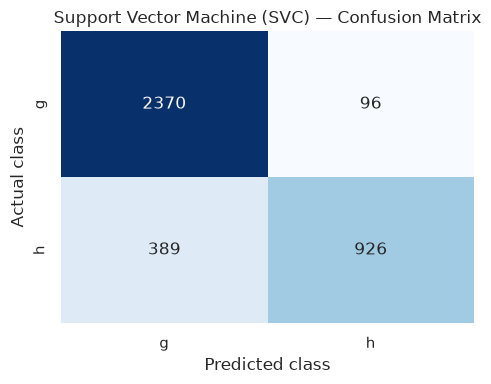

In [21]:
svc_model = evaluate_classifier(
    "Support Vector Machine (SVC)", svc_search.best_estimator_
)

### Model 5 takeaway

The selected kernel shows whether the data benefits from a nonlinear margin. Its final score is measured on the same untouched test set as the other four classifiers.

## 7. Part A comparison

Models are ranked by weighted F1 because the classes are imbalanced. Accuracy and ROC-AUC provide useful supporting views, while the confusion matrices show the actual error counts.

In [22]:
final_results = comparison_table()
display(final_results.round(4))

best_row = final_results.iloc[0]
print(f"Best Part A model by weighted F1: {best_row['Model']}")
print(f"Weighted F1: {best_row['F1 (weighted)']:.4f}")
print(f"Accuracy: {best_row['Accuracy']:.4f}")
print(f"ROC-AUC: {best_row['ROC-AUC']:.4f}")

Best Part A model by weighted F1: Support Vector Machine (SVC)
Weighted F1: 0.8673
Accuracy: 0.8717
ROC-AUC: 0.9209


                          Model  Accuracy  ...  F1 (weighted)  ROC-AUC
0  Support Vector Machine (SVC)    0.8717  ...         0.8673   0.9209
1      Decision Tree Classifier    0.8474  ...         0.8463   0.8895
2          K-Nearest Neighbours    0.8434  ...         0.8357   0.8952
3           Logistic Regression    0.7932  ...         0.7850   0.8392
4          Gaussian Naive Bayes    0.6683  ...         0.6762   0.7534

[5 rows x 6 columns]

<ipython-input-1-bea4fce46891>:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


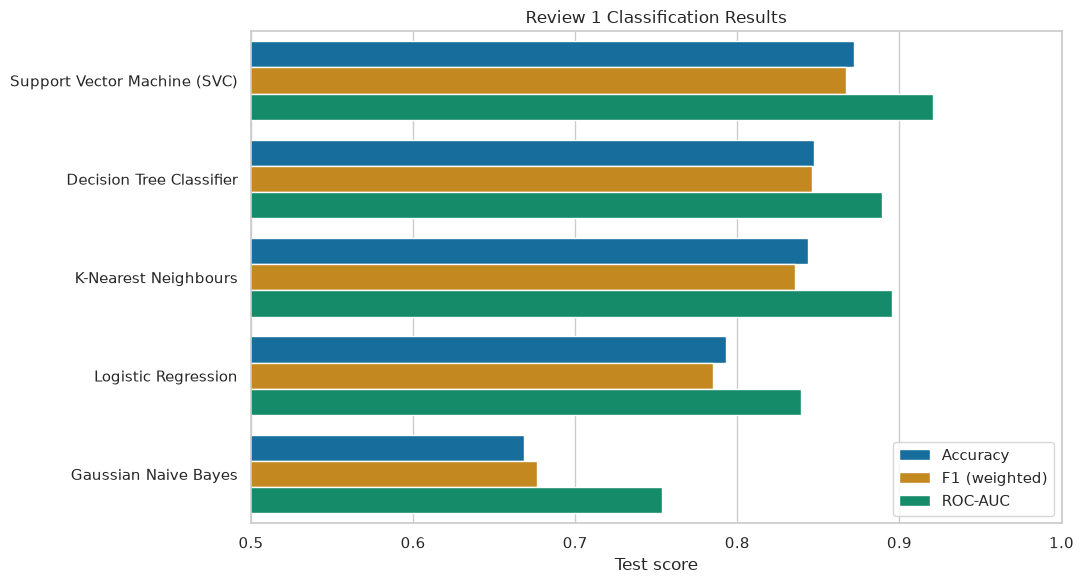

In [23]:
plot_data = final_results.melt(
    id_vars="Model",
    value_vars=["Accuracy", "F1 (weighted)", "ROC-AUC"],
    var_name="Metric",
    value_name="Score",
)

plt.figure(figsize=(11, 6))
sns.barplot(data=plot_data, x="Score", y="Model", hue="Metric")
plt.xlim(0.5, 1.0)
plt.title("Review 1 Classification Results")
plt.xlabel("Test score")
plt.ylabel("")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Review 1 conclusion

The table is the evidence for selecting the current Part A leader; it avoids assuming in advance that the most complex model will win. Review 2 can extend the same split, preprocessing rules, helper function, and comparison table with the remaining five classifiers.